## JR Analyst Python Home Exam - Second script
### 10/08/2025

## Data Cleaning:

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crime_df = pd.read_csv('nyc_crime_large.csv')

- `CMPLNT_FR_DT` : Date the crime occurred

- `OFNS_DESC` : Offense description

- `BORO_NM` : Borough

- `LAW_CAT_CD` : Crime severity

#### Time variables

In [9]:
crime_df['CMPLNT_FR_DT'] = pd.to_datetime(crime_df['CMPLNT_FR_DT'], errors='coerce')
# crime_df['CMPLNT_FR_DT'].describe(percentiles=[0.1,0.25,0.4,0.5,0.6,0.75,0.9])

In [10]:
crime_df['year'] = crime_df['CMPLNT_FR_DT'].dt.year
# print(crime_df['year'].unique())
crime_df['month'] = crime_df['CMPLNT_FR_DT'].dt.month
# print(crime_df['month'].unique())


crime_df['day'] = crime_df['CMPLNT_FR_DT'].dt.day_name()
# print(crime_df['day'].unique())
crime_df['quarter'] = crime_df['CMPLNT_FR_DT'].dt.quarter
# print(crime_df['quarter'].unique())

season_dict = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer'
}

crime_df['season'] = crime_df['month'].map(season_dict)
# print(crime_df['season'].unique())


crime_df['day_type'] = 'Weekday'
crime_df.loc[crime_df['day'].isin(['Saturday', 'Sunday']), 'day_type'] = 'Weekend'
# print(crime_df['day_type'].unique())

crime_df['day_in_month'] = crime_df['CMPLNT_FR_DT'].dt.day
# crime_df['day_in_month'].value_counts(ascending=False).tail(5) 

#### Cleaning messy categorial vars

In [11]:
# crime_df['OFNS_DESC'].unique()
crime_df['OFNS_DESC_fixed'] = crime_df['OFNS_DESC'].str.strip()
crime_df.loc[crime_df['OFNS_DESC_fixed']=='ASSAULT1', 'OFNS_DESC_fixed'] = 'ASSAULT'
crime_df.loc[crime_df['OFNS_DESC_fixed']=='BURGLARY_dev', 'OFNS_DESC_fixed'] = 'BURGLARY'
# crime_df['OFNS_DESC_fixed'].unique()

# crime_df['BORO_NM'].unique()
crime_df['BORO_NM_fixed'] = crime_df['BORO_NM'].str.strip()
# crime_df['BORO_NM_fixed'].unique()

#### Boroughs and Lat-Long seem unmatched

In [12]:
def plot_lat_long_scatter(df, lat_col, long_col, color_col):
    """
    Function to plot a scatter plot of latitude and longitude with points colored by a third categorial column.
    """
    plt.figure(figsize=(7, 4))

    if color_col == 'CMPLNT_FR_DT':
        return "Color column cannot be 'CMPLNT_FR_DT'. Please choose a different column."

    else:
        colors = ['teal', 'gainsboro', 'olivedrab', 'sienna', 'deeppink', 'goldenrod']
        categories = df[color_col].unique()
        for cat in categories:
            subset = df[df[color_col] == cat]
            plt.scatter(
                subset[long_col], subset[lat_col],
                label=cat, alpha=0.4, s=25,
                c = colors[categories.tolist().index(cat)] if cat in categories else 'red'
            )
        plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(long_col)
    plt.ylabel(lat_col)
    plt.title(f'Scatter plot of {lat_col} vs {long_col} colored by {color_col}')
    plt.grid(which='both', linestyle='--', alpha=0.7, linewidth=0.5)
    plt.tight_layout()
    plt.show()

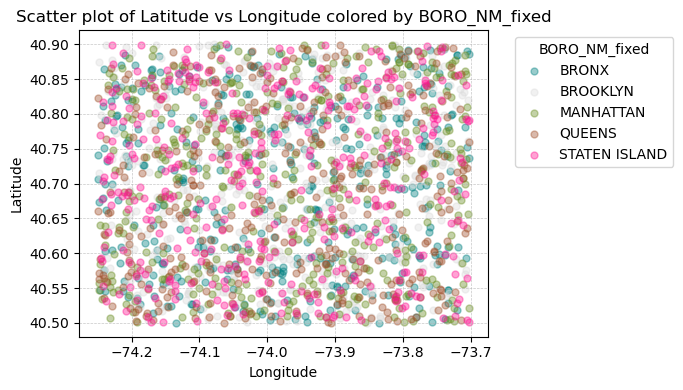

In [13]:
plot_lat_long_scatter(crime_df, 'Latitude', 'Longitude', 'BORO_NM_fixed')

#### Recreating `BORO_NM` with spatial analysis

Based on latitude and longitude and https://www.nyc.gov/content/planning/pages/resources/datasets/borough-boundaries (chat-GPT)

In [14]:
from shapely.geometry import Point
import geopandas as gpd

geometry = [Point(xy) for xy in zip(crime_df['Longitude'], crime_df['Latitude'])]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs='EPSG:4326')

boroughs = gpd.read_file(r"nybb_25b\nybbwi.shp")
boroughs = boroughs.to_crs('EPSG:4326')

geometry = [Point(xy) for xy in zip(crime_df['Longitude'], crime_df['Latitude'])]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")

crime_with_boro = gpd.sjoin(crime_gdf, boroughs, how="left", predicate="within")
crime_with_boro['Borough_geo'] = crime_with_boro['BoroName']

crime_df = crime_df.merge(crime_with_boro[['BoroName']],how='left',left_index=True,right_index=True)
crime_df.loc[crime_df['BoroName'].isna(), 'BoroName'] = 'Other'


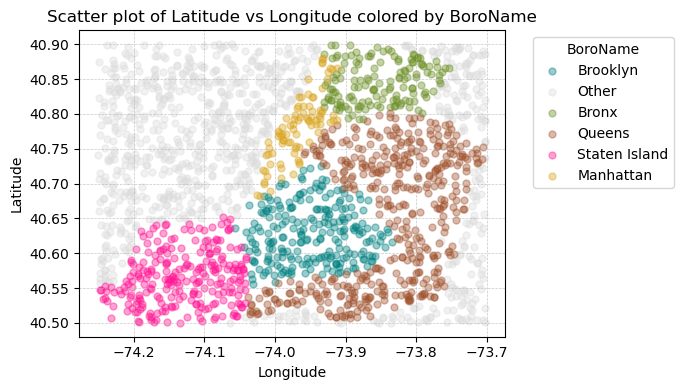

In [15]:
plot_lat_long_scatter(crime_df, 'Latitude', 'Longitude', 'BoroName')

### Analysis

- `CMPLNT_FR_DT` : Date the crime occurred (datetime)

- `year` | `quarter` | `season` | `month` | `day` | `day_type`

- `OFNS_DESC_fixed` : Offense description

- `BoroName` : Borough named fixed

- `LAW_CAT_CD` : Crime severity

### Histogram of calendar weeks (Amit)

[(0.0, 45.0)]

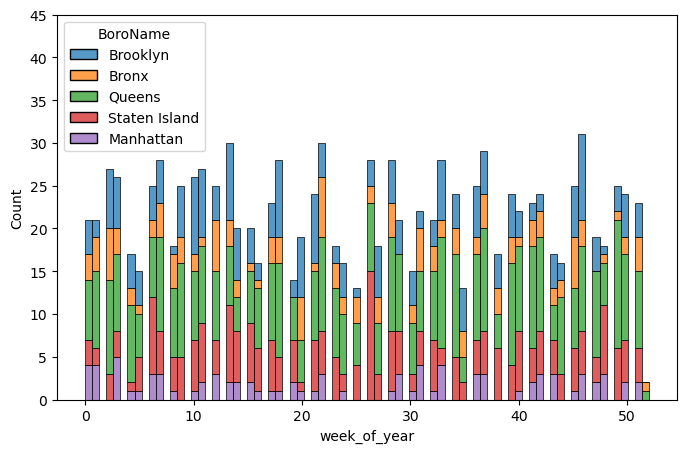

In [71]:
crime_df['day_of_year']=crime_df['CMPLNT_FR_DT'].dt.dayofyear
crime_df['week_of_year'] = crime_df['day_of_year']//7

nyc_df = crime_df[crime_df['BoroName']!='Other'].copy()


fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.histplot(
    data=nyc_df,
    x='week_of_year',
    element='bars',
    bins=80,
    multiple='stack',
    hue='BoroName',
    legend=True,
    ax=ax
    )
ax.set(ylim=[0,45])



In [47]:
nyc_df['week_of_year'].value_counts().sort_values(ascending=False).head(2)

week_of_year
46    31
13    30
Name: count, dtype: int64

##### Top 5 most common crime types:


In [85]:
def intersection_bar_plot(df, col1, col2, number_of_bars=None, val='count'):
    """
    Plots stacked bars showing the count of incidents per col1 split by col2.
    Each bar represents the count, and labels show % of each segment within col1.
    Bars are sorted by total number of incidents (descending).
    """
    d_names = {'BORO_NM_fixed': 'BOROUGH',
                'BoroName': 'BOROUGH',
                'LAW_CAT_CD': 'SEVERITY',
                'OFNS_DESC_fixed': 'CRIME TYPE',
                'year': 'YEAR',
                'month': 'MONTH',
                'day': 'DAY',
                'quarter': 'QUARTER',
                'day_type': 'DAY TYPE',
                'season': 'SEASON',
                'day_in_month':'DAY'}
    
    c = df.groupby([col1, col2]).size().reset_index(name='count')
    c['total'] = c.groupby(col1)['count'].transform('sum')
    c['percentage'] = c['count'] / c['total'] * 100

    # Sort col1 values by total count
    if col1 not in ['year', 'month','quarter','day_in_month']:
        sorted_totals = c.groupby(col1)['count'].sum().sort_values(ascending=False)
    else:
        # For 'year' and 'month', sort by the natural order
        sorted_totals = c.groupby(col1)['count'].sum().sort_index()

    if number_of_bars:
        sorted_totals = sorted_totals.head(number_of_bars)

    c_filtered = c[c[col1].isin(sorted_totals.index)]
    c_pivot = (c_filtered.pivot(index=col1, columns=col2, values=val).fillna(0).loc[sorted_totals.index])

    ax = c_pivot.plot(kind='bar', stacked=True, figsize=(12, 4))
    plt.title(f'Distribution of {d_names[col1]} and {d_names[col2]}')
    plt.ylabel(val.upper())
    plt.xlabel(d_names[col1])

    for col_idx, container in enumerate(ax.containers):
        for i, bar in enumerate(container):
            height = bar.get_height()
            if height > 0:
                total = c_pivot.iloc[i].sum()
                pct = height / total * 100
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f'{pct:.1f}%',
                    ha='center', va='center', fontsize=8, color='white'
                )

    plt.legend(title=d_names[col2], bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.5)
    plt.show()

NYC BOROUGHS ONLY:
OFNS_DESC_fixed
ROBBERY          135
VEHICLE THEFT    134
ASSAULT          130
BURGLARY         130
VANDALISM        130
Name: count, dtype: int64


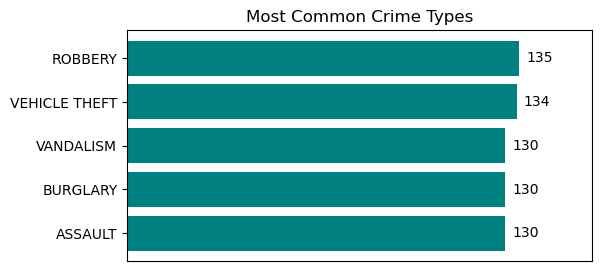

In [86]:
print("NYC BOROUGHS ONLY:")
print(nyc_df['OFNS_DESC_fixed'].value_counts().sort_values(ascending=False).head(5))

a_df = pd.DataFrame(nyc_df['OFNS_DESC_fixed'].value_counts().sort_values(ascending=True).tail(5))
a_df.reset_index(inplace=True)
a_df.columns = ['Crime Type', 'Count']


fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(a_df['Crime Type'],
        a_df['Count'],
        color='teal')

ax.set_title('Most Common Crime Types')
ax.set_xticks([])
ax.set_xlim(0, 160)

for i, v in enumerate(a_df['Count']):
    ax.text(v + 2.5, i, str(v), color='black', va='center')

plt.show()

### Trends over the Time

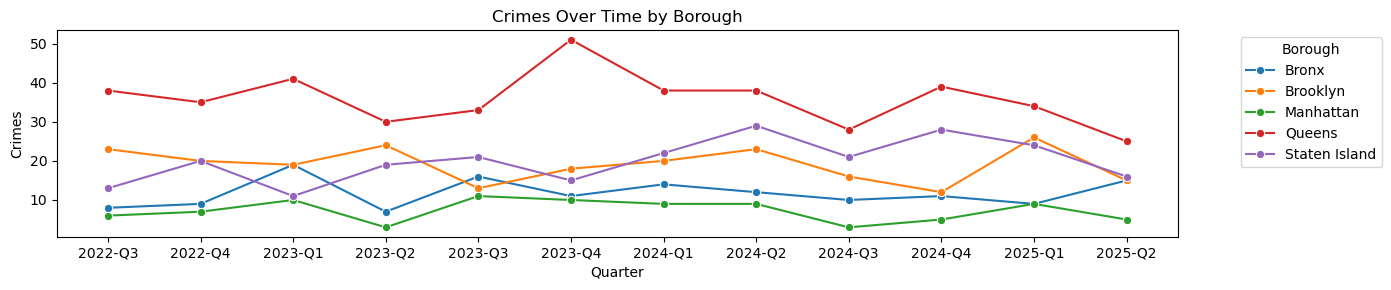

In [67]:
agg_df = (crime_df.groupby(['year', 'quarter', 'BoroName'], as_index=False).size().rename(columns={'size': 'crimes'}))
total_df = (agg_df.groupby(['year', 'quarter'], as_index=False)['crimes'].sum().assign(BoroName='Total'))
final_df = pd.concat([agg_df, total_df], ignore_index=True).sort_values(by=['year','quarter'])
final_df['date'] = (final_df['year'].astype(str) + '-Q' + final_df['quarter'].astype(str).str.zfill(1))


boro_df = final_df[(final_df['BoroName']!='Other') &
                    ((final_df['BoroName']!='Total')) &
                      (final_df['date']!='2025-Q3') ]

plt.figure(figsize=(14, 3))
sns.lineplot(data=boro_df,x='date',y='crimes',hue='BoroName',marker='o')

plt.xticks(rotation=0)
plt.xlabel('Quarter')
plt.ylabel('Crimes')
plt.title('Crimes Over Time by Borough')
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

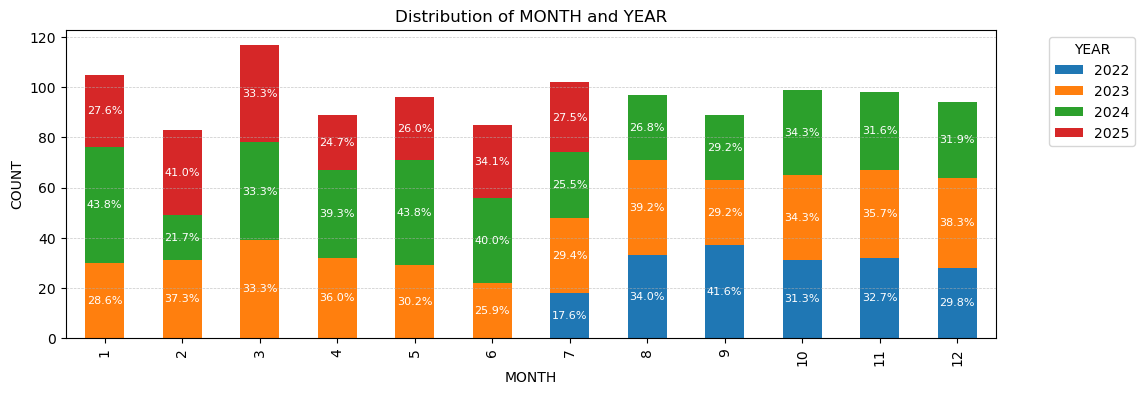

In [68]:
intersection_bar_plot(nyc_df,'month', 'year', number_of_bars=None)

# שנה - משתנה בעייתי כי 2022 ו2025 לא מלאות. אבל בדאטה יש חודשים מלאים (גם יולי), 
# לכן נוח להשוות חודשים - חודש מרץ הוא הבולט ביותר 
# גם ינואר יולי אוקטובר ונובמבר עם מספר גדול של מקרי פשיעה

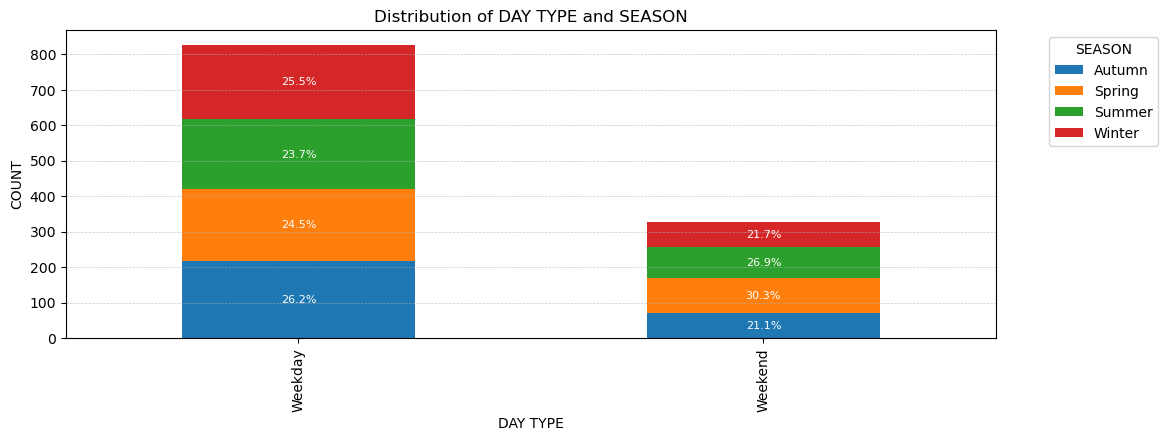

In [71]:
intersection_bar_plot(nyc_df, 'day_type','season',
                      number_of_bars=None)#, val='percentage')

##### The 3 boroughs with the highest number of crimes

BoroName
Other            846
Queens           439
Staten Island    250
Brooklyn         235
Name: count, dtype: int64


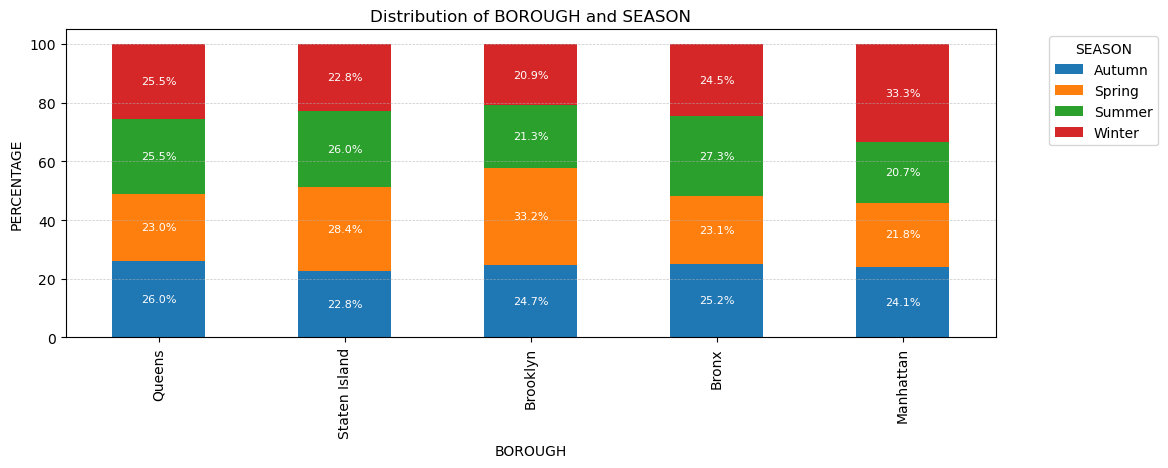

In [19]:
print(crime_df['BoroName'].value_counts().sort_values(ascending=False).head(4))
intersection_bar_plot(nyc_df,'BoroName', 'season',
                       number_of_bars=5, val='percentage')

# בברוקלין אירועים שכיחים יותר באביב מאשר בשאר העונות, במנהטן אירועי פשיעה בחורף נפוצים יותר 

In [55]:
severity_levels = ['VIOLATION',
                   'MISDEMEANOR',
                   'FELONY']

total = nyc_df["LAW_CAT_CD"].count()
for severity in severity_levels:
    count = nyc_df[nyc_df['LAW_CAT_CD'] == severity].shape[0]
    print(f'There are {count} crimes classified as {severity} in NYC boroughs, accounting for {(count / total) * 100:.2f}% of the total.')
    print("-" * 80)

There are 105 crimes classified as VIOLATION in NYC boroughs, accounting for 9.10% of the total.
--------------------------------------------------------------------------------
There are 484 crimes classified as MISDEMEANOR in NYC boroughs, accounting for 41.94% of the total.
--------------------------------------------------------------------------------
There are 565 crimes classified as FELONY in NYC boroughs, accounting for 48.96% of the total.
--------------------------------------------------------------------------------


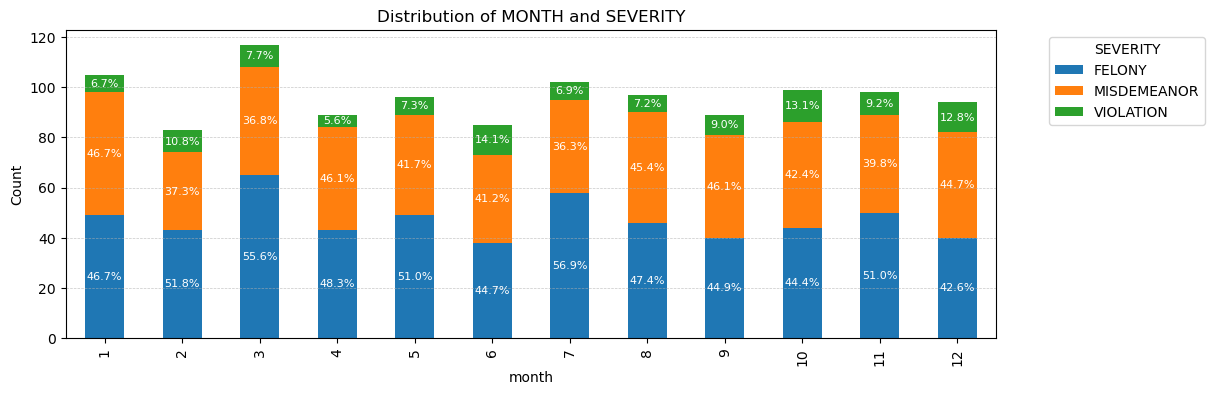

In [79]:
intersection_bar_plot(nyc_df,
                       'month','LAW_CAT_CD', number_of_bars=None)

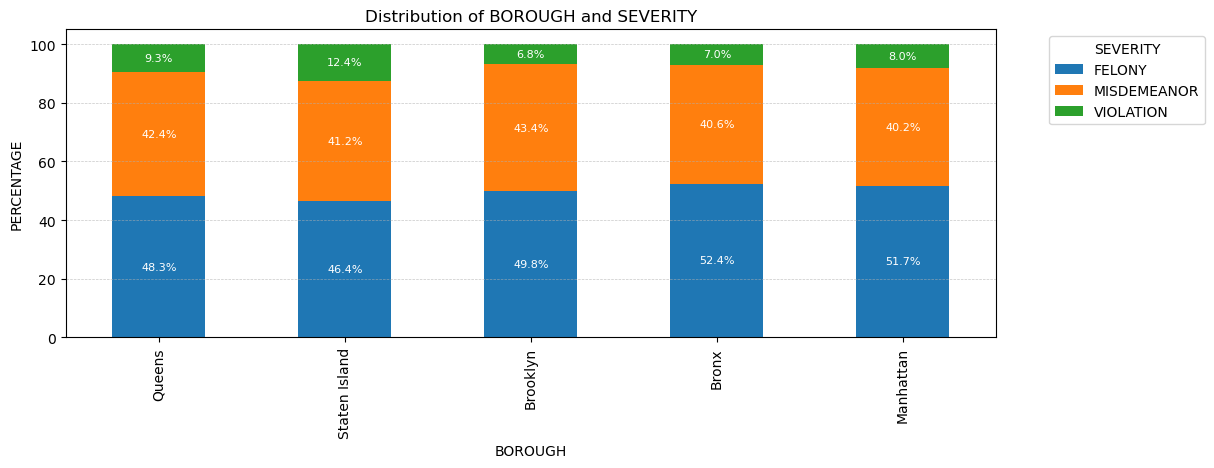

In [147]:
intersection_bar_plot(nyc_df,
                       'BoroName','LAW_CAT_CD', number_of_bars=None, val='percentage')